In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better plots
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)


In [2]:
# Read TensorBoard event file using protobuf (no TensorFlow DLL needed)
import struct
from google.protobuf.message import DecodeError

def read_event_file(filepath):
    """Parse TensorFlow event file without loading TensorFlow native libs"""
    events_data = []
    try:
        with open(filepath, 'rb') as f:
            while True:
                # Read record length
                length_bytes = f.read(8)
                if not length_bytes:
                    break
                    
                # Read record
                length = struct.unpack('Q', length_bytes)[0]
                record = f.read(length)
                
                # Skip checksum
                f.read(4)
                
                try:
                    # Try to parse as protobuf (simplified)
                    events_data.append(record)
                except Exception as e:
                    print(f"Could not parse record: {e}")
                    
    except FileNotFoundError:
        print(f"Event file not found: {filepath}")
    
    return events_data

# Load events
event_file = 'tensorboard/PPO_1/events.out.tfevents.1777367872.localhost.38099.0'
events = read_event_file(event_file)
print(f"Loaded {len(events)} events from TensorBoard log")

# Alternatively, use tensorboard CLI to convert to JSON
print("\nTo view in TensorBoard, run:")
print("tensorboard --logdir=tensorboard --port=6006")


MemoryError: 

In [3]:
# Read CSV metrics
df = pd.read_csv('runs/20260428_144742/metrics.csv')
print(f"Data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
print(df.head())


Data shape: (58, 10)
Columns: ['timesteps', 'episode_reward', 'episode_len', 'resolution_rate', 'escalation_rate', 'dropout_rate', 'timeout_rate', 'mean_reward_100ep', 'mean_episode_length_100ep', 'episodes_seen']

   timesteps  episode_reward  episode_len  resolution_rate  escalation_rate  \
0        500       -3.870971         3.60         0.023810         0.928571   
1       1000       -3.048733         3.83         0.082192         0.876712   
2       1500       -3.597988         3.93         0.094828         0.853448   
3       2000       -3.618785         3.65         0.087500         0.850000   
4       2500       -2.608328         3.27         0.126984         0.809524   

   dropout_rate  timeout_rate  mean_reward_100ep  mean_episode_length_100ep  \
0      0.047619           0.0          -3.870971                       3.60   
1      0.041096           0.0          -3.048733                       3.83   
2      0.051724           0.0          -3.597988                       3.

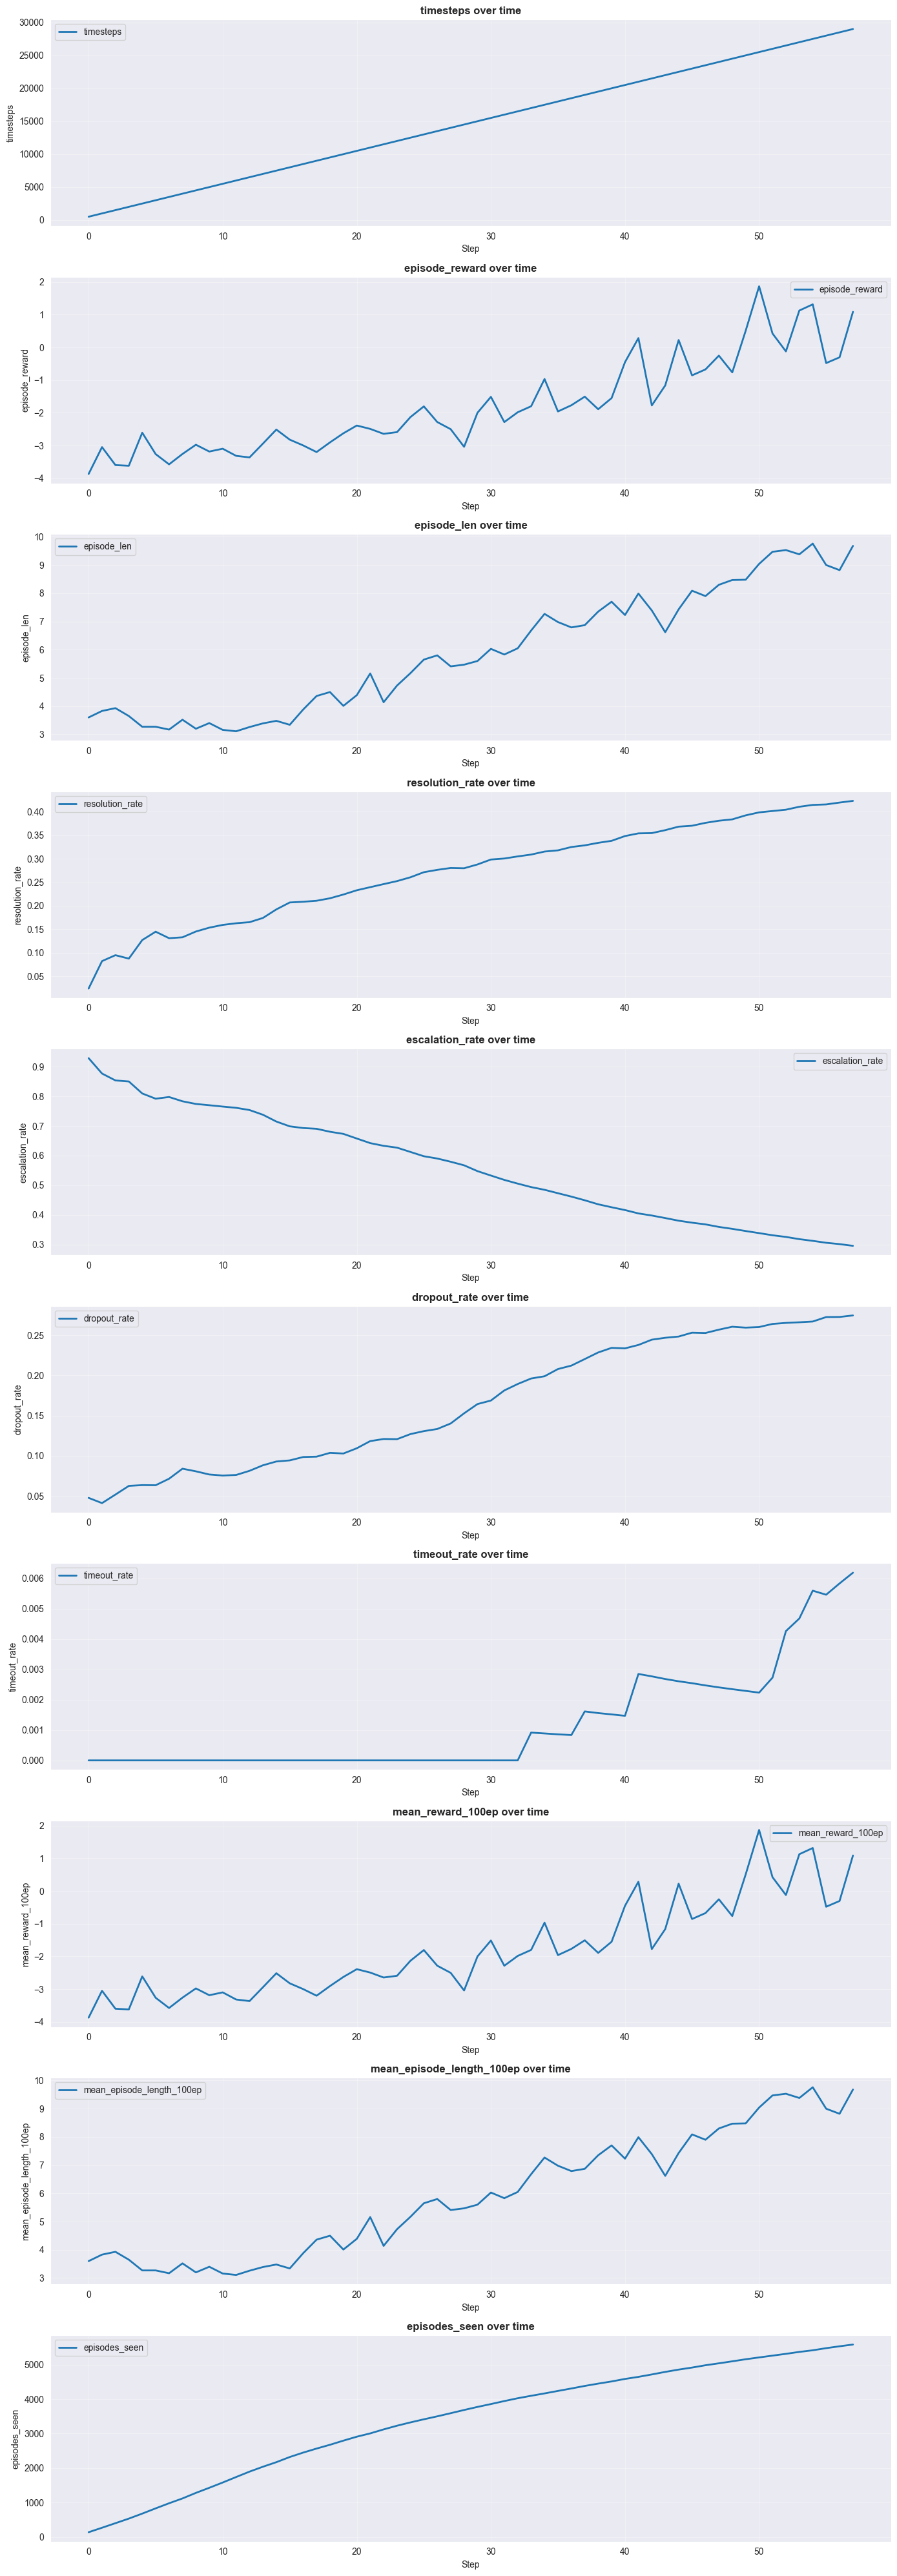

Metrics summary:
          timesteps  episode_reward  episode_len  resolution_rate  \
count     58.000000       58.000000    58.000000        58.000000   
mean   14750.000000       -1.790493     5.913448         0.272719   
std     8443.439268        1.436493     2.157771         0.103999   
min      500.000000       -3.870971     3.110000         0.023810   
25%     7625.000000       -2.967376     3.842500         0.195910   
50%    14750.000000       -2.064243     5.725000         0.284118   
75%    21875.000000       -0.786294     7.632500         0.359266   
max    29000.000000        1.868322     9.760000         0.423132   

       escalation_rate  dropout_rate  timeout_rate  mean_reward_100ep  \
count        58.000000     58.000000     58.000000          58.000000   
mean          0.561491      0.164590      0.001200          -1.790493   
std           0.182234      0.078147      0.001747           1.436493   
min           0.296050      0.041096      0.000000          -3.870971

In [4]:
# Plot all metrics as time series
fig, axes = plt.subplots(len(df.columns), 1, figsize=(14, 4*len(df.columns)))
if len(df.columns) == 1:
    axes = [axes]

for idx, col in enumerate(df.columns):
    axes[idx].plot(df[col], linewidth=2, label=col)
    axes[idx].set_title(f"{col} over time", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Step')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("Metrics summary:")
print(df.describe())


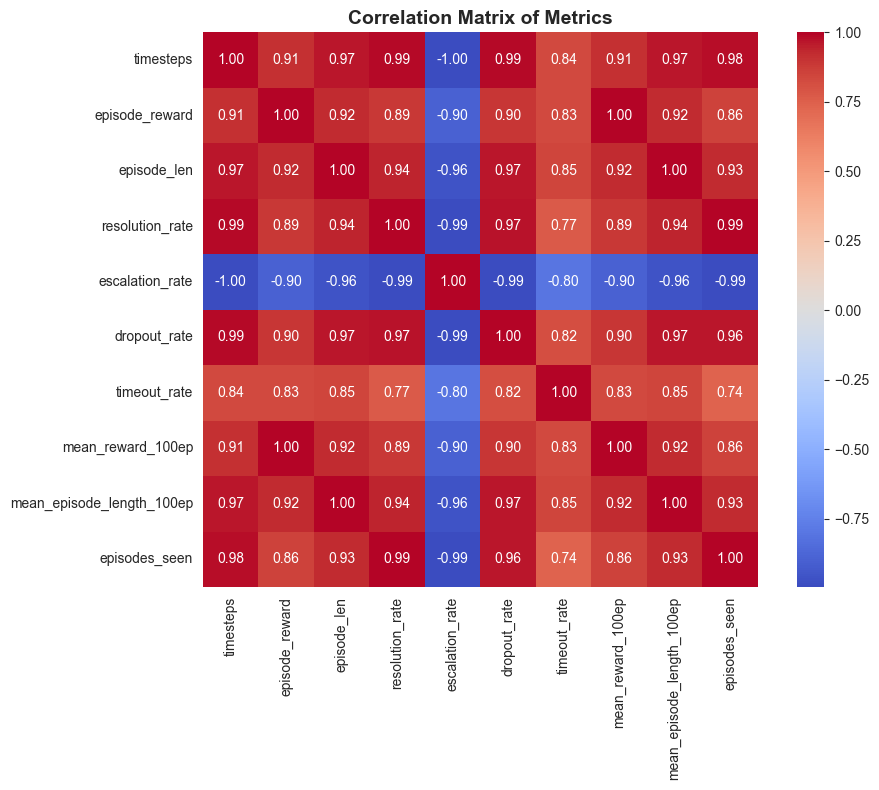

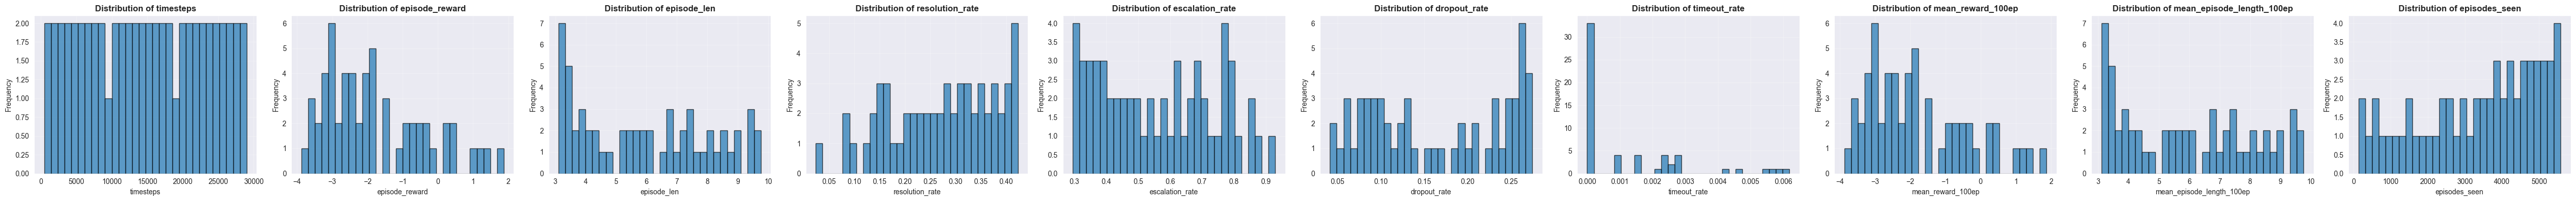

In [5]:
# Correlation heatmap and distribution plots
if len(df.columns) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Matrix of Metrics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Distribution plots
fig, axes = plt.subplots(1, len(df.columns), figsize=(5*len(df.columns), 4))
if len(df.columns) == 1:
    axes = [axes]

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Distribution of {col}", fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
